<a href="https://colab.research.google.com/github/palakchanchlani/startup-funding-ml/blob/main/startup.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

# GitHub raw link
url = "https://raw.githubusercontent.com/johnreygoh/datasets/master/startup_funding.csv"

# Read CSV
df = pd.read_csv(url)

print("Rows, Columns:", df.shape)
df.head()


Rows, Columns: (3044, 10)


,Sr No,Date dd/mm/yyyy,Startup Name,Industry Vertical,SubVertical,City Location,Investors Name,InvestmentnType,Amount in USD,Remarks
0,1,09/01/2020,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,"20,00,00,000",NaN
1,2,13/01/2020,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,"80,48,394",NaN
2,3,09/01/2020,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,"1,83,58,860",NaN
3,4,02/01/2020,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,"30,00,000",NaN
4,5,02/01/2020,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,"18,00,000",NaN


In [3]:
print(df.columns.tolist())


['Sr No', 'Date dd/mm/yyyy', 'Startup Name', 'Industry Vertical', 'SubVertical', 'City  Location', 'Investors Name', 'InvestmentnType', 'Amount in USD', 'Remarks']


In [4]:
# Clean column names (already done)
df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]

# Convert date column (actual name: 'date_dd/mm/yyyy')
df['date_dd/mm/yyyy'] = pd.to_datetime(df['date_dd/mm/yyyy'], errors='coerce')

# Clean amount column (actual name: 'amount_in_usd')
df['amount_in_usd'] = (
    df['amount_in_usd']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.extract(r'(\d+\.?\d*)')[0]
    .astype(float)
)

# Drop fully empty rows
df = df.dropna(how='all')

print("Cleaned shape:", df.shape)


Cleaned shape: (3044, 10)


In [5]:
print("\nTop cities:\n", df['city__location'].value_counts().head(10))
print("\nTop industries:\n", df['industry_vertical'].value_counts().head(10))
print("\nInvestment types:\n", df['investmentntype'].value_counts().head(10))
print("\nFunding amount stats:\n", df['amount_in_usd'].describe())



Top cities:
 city__location
Bangalore    700
Mumbai       567
New Delhi    421
Gurgaon      287
Bengaluru    141
Pune         105
Hyderabad     99
Chennai       97
Noida         92
Gurugram      50
Name: count, dtype: int64

Top industries:
 industry_vertical
Consumer Internet    941
Technology           478
eCommerce            186
Healthcare            70
Finance               62
ECommerce             61
Logistics             32
E-Commerce            29
Education             24
Food & Beverage       23
Name: count, dtype: int64

Investment types:
 investmentntype
Private Equity          1356
Seed Funding            1355
Seed/ Angel Funding       60
Seed / Angel Funding      47
Seed\\nFunding            30
Debt Funding              25
Series A                  24
Seed/Angel Funding        23
Series B                  20
Series C                  14
Name: count, dtype: int64

Funding amount stats:
 count    2.077000e+03
mean     1.833032e+07
std      1.210296e+08
min      2.000000e+00

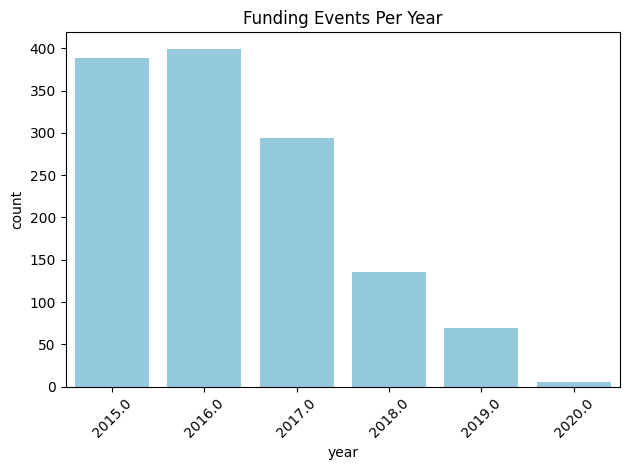

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Yearly funding events
df['year'] = df['date_dd/mm/yyyy'].dt.year

sns.countplot(x='year', data=df, color='skyblue')
plt.title("Funding Events Per Year")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


/tmp/ipython-input-222288418.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cities.index, y=top_cities.values, palette="viridis")


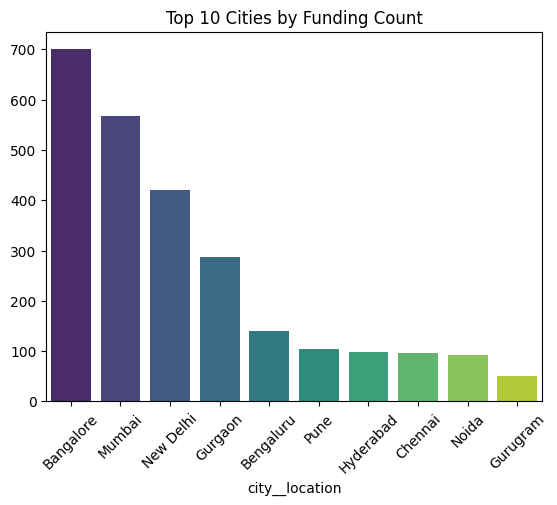

/tmp/ipython-input-222288418.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_industries.index, y=top_industries.values, palette="mako")


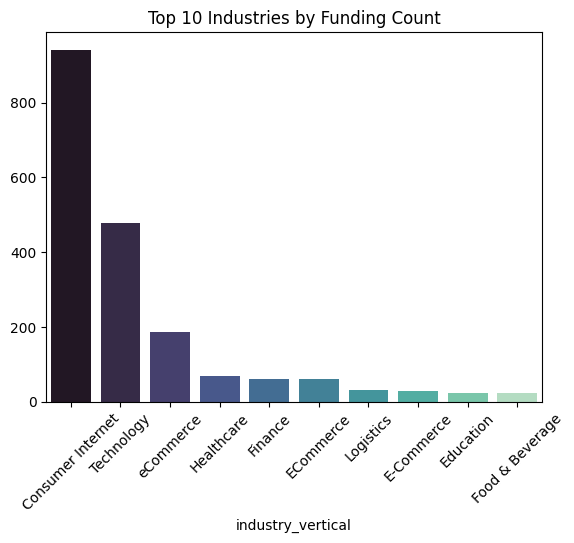

/tmp/ipython-input-222288418.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_investments.index, y=top_investments.values, palette="coolwarm")


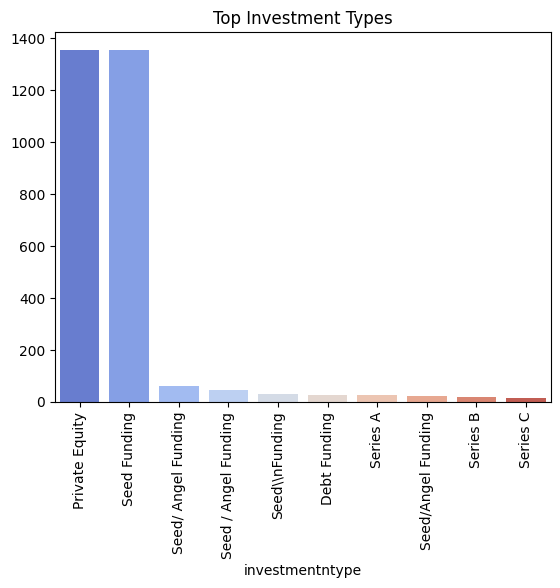

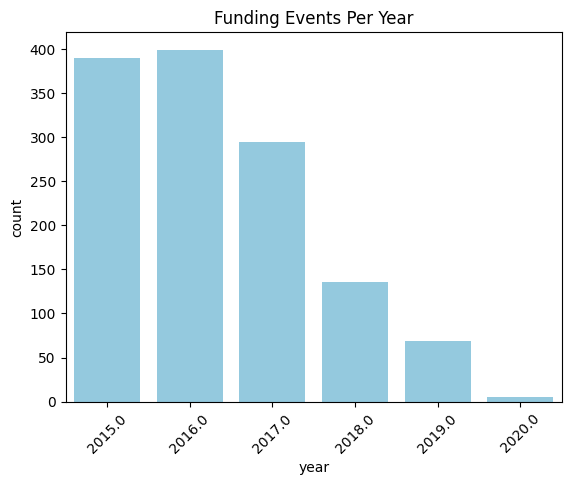

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. City-wise funding activity
top_cities = df['city__location'].value_counts().head(10)
sns.barplot(x=top_cities.index, y=top_cities.values, palette="viridis")
plt.title("Top 10 Cities by Funding Count")
plt.xticks(rotation=45)
plt.show()

# 2. Industry-wise distribution
top_industries = df['industry_vertical'].value_counts().head(10)
sns.barplot(x=top_industries.index, y=top_industries.values, palette="mako")
plt.title("Top 10 Industries by Funding Count")
plt.xticks(rotation=45)
plt.show()

# 3. Investment type breakdown
top_investments = df['investmentntype'].value_counts().head(10)
sns.barplot(x=top_investments.index, y=top_investments.values, palette="coolwarm")
plt.title("Top Investment Types")
plt.xticks(rotation=90)
plt.show()

# 4. Yearly funding trend
df['year'] = df['date_dd/mm/yyyy'].dt.year
sns.countplot(x='year', data=df, color='skyblue')
plt.title("Funding Events Per Year")
plt.xticks(rotation=45)
plt.show()


In [8]:
X = df[['city__location', 'industry_vertical', 'investmentntype']]
y = df['amount_in_usd']

X_encoded = pd.get_dummies(X, drop_first=True)


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)


In [10]:
# Drop rows where target is NaN
df_model = df.dropna(subset=['amount_in_usd']).copy()

# Select features and target
X = df_model[['city__location', 'industry_vertical', 'investmentntype']]
y = df_model['amount_in_usd']

# Encode categorical features
X_encoded = pd.get_dummies(X, drop_first=True)


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)


In [12]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# RMSE calculation (manual to avoid version issues)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("Baseline RMSE:", rmse)


Baseline RMSE: 133798187.59482542


In [13]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 400],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Params:", grid_search.best_params_)
best_model = grid_search.best_estimator_

y_pred_best = best_model.predict(X_test)
best_mse = mean_squared_error(y_test, y_pred_best)
best_rmse = np.sqrt(best_mse)
print("Tuned RMSE:", best_rmse)


Best Params: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
Tuned RMSE: 133585258.33519104


In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    print(f"{name} RMSE: {rmse}")


Linear Regression RMSE: 134074232.07918528
Decision Tree RMSE: 133548684.97690414
Random Forest RMSE: 133798187.59482542
Gradient Boosting RMSE: 135804770.12100294


In [15]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Random Forest tuning
rf_param_grid = {
    'n_estimators': [100, 200, 400],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    rf_param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
rf_grid.fit(X_train, y_train)
print("Best RF Params:", rf_grid.best_params_)
print("Best RF RMSE:", np.sqrt(mean_squared_error(y_test, rf_grid.best_estimator_.predict(X_test))))

# Gradient Boosting tuning
gb_param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5, 10]
}

gb_grid = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    gb_param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
gb_grid.fit(X_train, y_train)
print("Best GB Params:", gb_grid.best_params_)
print("Best GB RMSE:", np.sqrt(mean_squared_error(y_test, gb_grid.best_estimator_.predict(X_test))))


Best RF Params: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
Best RF RMSE: 133585258.33519104
Best GB Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}
Best GB RMSE: 134968804.24268147


Top Features:
 industry_vertical_Transportation         0.391974
city__location_Bangalore                 0.107067
investmentntype_Seed Funding             0.072932
industry_vertical_ECommerce              0.050438
city__location_Bengaluru                 0.046250
industry_vertical_Online Marketplace     0.038623
city__location_Mumbai                    0.029507
investmentntype_Private Equity           0.027496
industry_vertical_eCommerce              0.025214
investmentntype_Series D                 0.019480
investmentntype_Private Equity Round     0.017136
investmentntype_Series B                 0.016194
industry_vertical_Consumer Internet      0.015130
industry_vertical_Health and Wellness    0.013647
investmentntype_Series C                 0.012824
dtype: float64


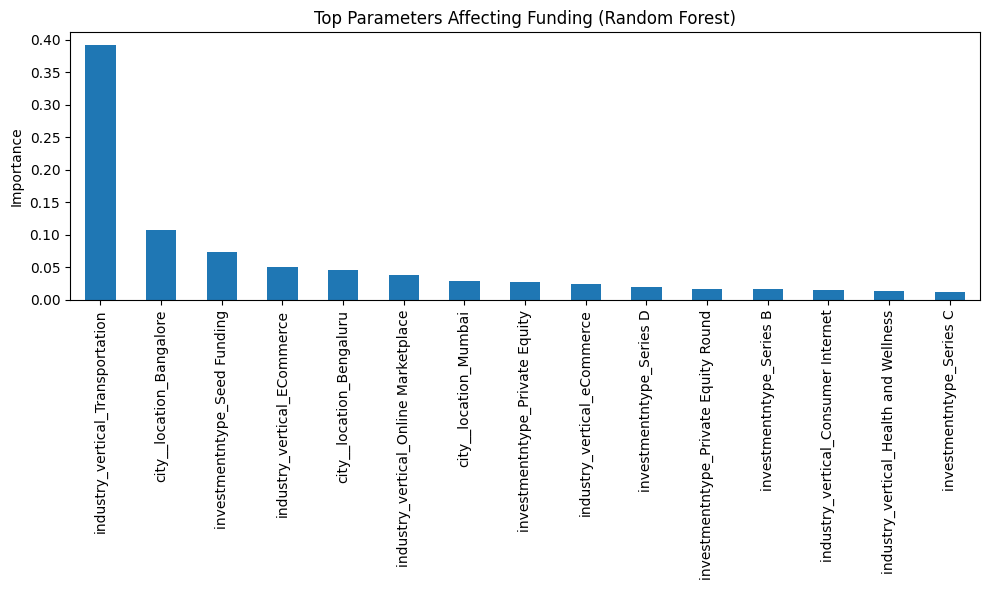

In [16]:
import matplotlib.pyplot as plt
import pandas as pd

# Feature importance from best RF model
importances = pd.Series(best_model.feature_importances_, index=X_encoded.columns)
top_importances = importances.sort_values(ascending=False).head(15)

print("Top Features:\n", top_importances)

plt.figure(figsize=(10,6))
top_importances.plot(kind='bar')
plt.title("Top Parameters Affecting Funding (Random Forest)")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()


In [17]:
import pickle

# Save the trained Random Forest model
with open("random_forest_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

# Later load the model
with open("random_forest_model.pkl", "rb") as f:
    loaded_model = pickle.load(f)
